# Building a Neural Network to Approximate a Franks NPZ Model

### Plan: NN and PINN for the Franks NPZ Model

1. **Standard Neural Network (NN)** trained only on simulated concentration data: nutrients (N), phytoplankton (P), and zooplankton (Z).
2. **Physics-Informed Neural Network (PINN)** trained on both the observational data and the **Franks et al. (1986)** NPZ equations, using automatic differentiation to enforce physical consistency.

---

### Step 1: Define the Franks NPZ Model

We consider the **nonlinear NPZ model** (Franks et al., 1986), which describes interactions among nutrients (N), phytoplankton (P), and zooplankton (Z):

$$
\begin{aligned}
\frac{dP}{dt} &= \frac{V_m N}{k_s + N} P - mP - \Lambda P R_m (1 - e^{-\Lambda P}) Z \\\\
\frac{dZ}{dt} &= (1 - \gamma) \Lambda P R_m (1 - e^{-\Lambda P}) Z - qZ \\\\
\frac{dN}{dt} &= -\frac{V_m N}{k_s + N} P + mP + qZ + \gamma \Lambda P R_m (1 - e^{-\Lambda P}) Z
\end{aligned}
$$

#### Variable meanings:

* \$N(t)\$: nutrient concentration (μg N L⁻¹)
* \$P(t)\$: phytoplankton biomass (μg N L⁻¹)
* \$Z(t)\$: zooplankton biomass (μg N L⁻¹)

#### Parameters:

| Parameter   | Description                          | Value          |
| ----------- | ------------------------------------ | -------------- |
| \$V\_m\$    | Maximum phytoplankton growth rate    | 2 day⁻¹        |
| \$k\_s\$    | Half-saturation constant for nitrate | 1 μg N L⁻¹     |
| \$m\$       | Phytoplankton mortality rate         | 0.1 day⁻¹      |
| \$\gamma\$  | Fraction of unassimilated grazing    | 0.3 (unitless) |
| \$R\_m\$    | Maximum zooplankton grazing rate     | 1.5 day⁻¹      |
| \$\Lambda\$ | Ivlev constant                       | 1 μg N L⁻¹     |
| \$q\$       | Zooplankton mortality rate           | 0.2 day⁻¹      |

---

### Step 2: Implementation Overview

* **Generate synthetic trajectories** for (N, P, Z) using a numerical integrator (e.g., Runge–Kutta 4).
* **Train a neural network (NN)** to learn the mapping $t \mapsto (N, P, Z)$ from time-series observations.
* **Train a physics-informed neural network (PINN)** that:

  * Uses the same architecture as the NN,
  * Minimizes both data loss and residuals from the Franks NPZ equations,
  * Computes time derivatives and enforces physical dynamics via a collocation loss.
* **Compare** the NN and PINN predictions against the ground truth trajectories to evaluate performance and physical consistency.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

### Implementing the NPZ model equations and Runge-Kutta scheme

In [2]:
def npz_nl(x, t, p):
    '''
    x: model state at time t
    t: current time
    p: dictionary of model parameters
    '''
    x = np.asarray(x)
    dx = np.zeros_like(x)

    uptake_term = ((p['Vm'] * x[0]) / (p['ks'] + x[0])) * x[1]
    grazing_term = (p['ivlev'] * x[1] * p['Rm'] * (1 - np.exp(-p['ivlev'] * x[1])) * x[2])
    
    dx[0] = -uptake_term + (p['m'] * x[1]) + (p['q'] * x[2]) + p['gamma'] * grazing_term
    dx[1] = uptake_term - (p['m'] * x[1]) - grazing_term
    dx[2] = (1 - p['gamma']) * grazing_term - (p['q'] * x[2])
    
    return dx


def rk4(f, x0, times, tfrc, frc, args):
    """
    Integrate an ODE system using the classical fourth-order Runge-Kutta method.
    Optionally add discrete forcing increments at specified forcing times.
    """
    nt = len(times)
    x = np.zeros((nt, len(x0)))
    x[0, :] = x0

    dt = np.zeros(nt)
    dt[1:] = np.diff(times)

    for n in range(1, nt):
        k1 = f(x[n - 1, :], times[n - 1], *args) * dt[n]
        k2 = f(x[n - 1, :] + 0.5 * k1, times[n - 1] + 0.5 * dt[n], *args) * dt[n]
        k3 = f(x[n - 1, :] + 0.5 * k2, times[n - 1] + 0.5 * dt[n], *args) * dt[n]
        k4 = f(x[n - 1, :] + k3, times[n - 1] + dt[n], *args) * dt[n]

        x[n, :] = x[n - 1, :] + (k1 + 2 * k2 + 2 * k3 + k4) / 6

        if tfrc is not None and frc is not None:
            fl = np.where(
                np.logical_and(
                    tfrc >= times[n] - 0.5 * dt[n],
                    tfrc < times[n] + 0.5 * dt[n]
                )
            )[0]
            x[n, :] += frc[fl, :].sum(axis=0)

    return x

## Generating Synthetic Data and Sparse Observations

We generate a "true" trajectory from the NPZ system using RK4 integration.

To mimic real-world data, we do not observe the system continuously. Instead:
- We sample a small number of observation times
- We add noise to the observations
- Some variables may be unobserved at certain times

Missing observations are represented using `NaN`, which we will handle later when defining the loss function.

### User-defined parameters

In [3]:
# select which variables are being observed (string such as 'NP', 'P', or 'NPZ')
vars_observed = 'NP'

# relative error (standard deviation) applied to parameter values before PINN experiment
relerror_param = 0.1

# observation error (standard deviation) applied in observation generation
error_obs = 0.03

# time-index for slicing "true" trajectory to build training data
i_t_obs = slice(0, 700, 10)

# Franks NPZ model reference parameters (used to generate synthetic observations for training data)
parameters = {
    'Vm':    2.0,   # maximum growth rate (day⁻¹)
    'ks':    1.0,   # half-saturation constant (µgN/L)
    'm':     0.1,   # mortality rate (day⁻¹)
    'gamma': 0.3,   # unassimilated grazing fraction
    'Rm':    1.5,  # max grazing rate (day⁻¹)
    'ivlev': 1.0,   # Ivlev constant (µgN/L)
    'q':     0.2,   # Z mortality (day⁻¹)
}


### Evaluating the user-defined parameters

In [4]:
i_obs = np.array(['NPZ'.index(letter) for letter in vars_observed])

# tensorflow does not allow integer arrays as indices
if len(vars_observed) == 1:
    i = 'NPZ'.index(vars_observed)
    i_obs_slice = slice(i, i+1)
elif len(vars_observed) >= 3:
    i_obs_slice = slice(None)
elif np.all(i_obs == [0, 1]):
    i_obs_slice = slice(None, 2)
elif np.all(i_obs == [0, 2]):
    i_obs_slice = slice(None, None, 2)
elif np.all(i_obs == [1, 2]):
    i_obs_slice = slice(1, None)

assert np.array_equal(np.arange(3)[i_obs], np.arange(3)[i_obs_slice]), 'Failed index check.'

### Helper function

In [5]:
colors_var = {'N': 'steelblue', 'P': 'seagreen', 'Z': 'lightcoral'}

def plot_result(t_data, state_data, t_est, state_est, t_true=None, state_true=None,
                epoch=None, data_label='training data', model_label='NN', show=False):
    
    fig, ax = plt.subplots(figsize=(10, 6))

    for istate, var in enumerate('NPZ'):
        color = colors_var[var]
        ax.plot(np.asarray(t_est), np.asarray(state_est[:, istate]), color=color, label=f'{var} {model_label} estimate', zorder=1.1)
        if state_true is not None:
            ax.plot(t_true, state_true[:, istate], color=color, ls='--', alpha=0.5, lw=5, label=f'{var} "true" trajectory', zorder=1.0)
        if istate in i_obs:
            ii = np.flatnonzero(i_obs == istate)[0]
            ax.plot(t_data, state_data[:, ii], color=color, ls='none', marker='o', label=f'{var} {data_label}', zorder=1.2)

    title = None
    if epoch is not None:
        title = f'{model_label} epoch {epoch}'
    ax.legend(title=title)
    ax.set(xlabel='time', ylabel='biomass (μg N L$^{-1}$)')
    
    ax.grid(True)
    if show:
        plt.show()
    return ax

### Running the NPZ model using reference parameters and creating "synthetic" observations

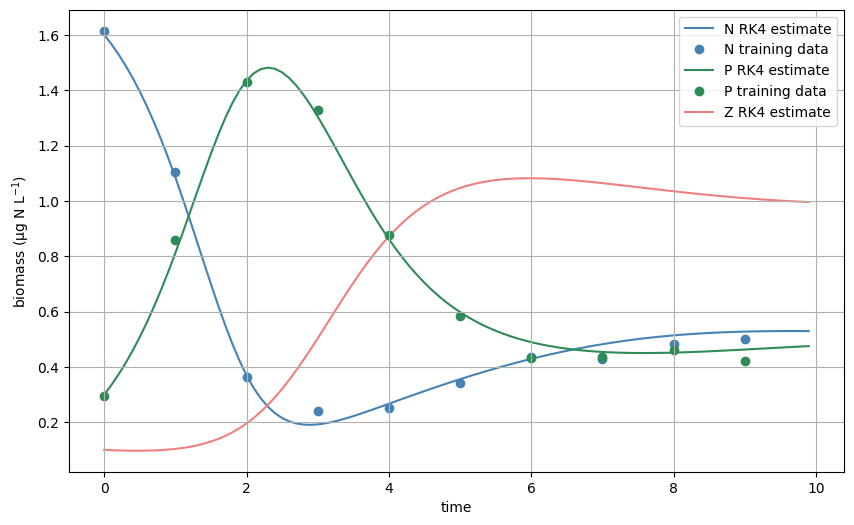

In [6]:
N0, P0, Z0 = 1.6, 0.3, 0.1
x0 = np.array([N0, P0, Z0])
T = 10.0
dt = 0.1
t_full = np.arange(0, T, dt)

# integrate NPZ model
state = rk4(npz_nl, x0, t_full, tfrc=None, frc=None, args=(parameters,))

t_obs = t_full[i_t_obs]
state_obs = state[i_t_obs, :][:, i_obs]
state_obs += error_obs * np.random.normal(size=state_obs.shape)

plot_result(t_obs, state_obs, t_full, state, data_label='training data', model_label='RK4')
None

## Building a Neural Network

We use a feedforward neural network to map time `t` to the populations `[P(t), Z(t)]`.

Instead of using `model.fit()`, we train the model with an explicit `tf.GradientTape` loop.

This is not strictly necessary for a standard neural network, but it becomes important for physics-informed neural networks (PINNs), where we need derivatives of the network output with respect to time.

Using the same training structure for both models makes it easier to introduce the physics-based loss later.

In [ ]:
# Neural networks learn by adjusting weights from their starting values.
# Poor initialization can cause gradients to vanish or explode,
# making training slow or unstable. Xavier/Glorot initialization
# scales weights based on layer size to keep gradients well-behaved.
# -------------------------------------------------
# Neural network architecture
# Input: time t
# Output: [N(t), P(t), Z(t)]

init_nn = tf.keras.initializers.GlorotUniform()

num_hidden_neurons = 64
num_output_neurons = 3

model_nn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(num_hidden_neurons, activation='gelu', kernel_initializer=init_nn),
    tf.keras.layers.Dense(num_hidden_neurons, activation='gelu', kernel_initializer=init_nn),
    tf.keras.layers.Dense(num_hidden_neurons, activation='gelu', kernel_initializer=init_nn),
    tf.keras.layers.Dense(num_output_neurons)
])
# Adam = adaptive gradient descent (works well out of the box)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

### Training Setup

We define the number of training epochs and the epochs at which we will visualize the model prediction.

We also prepare a mask so that the loss is only computed where observations are available.

In [ ]:
n_epochs = 5000
plot_epochs = [0, 100, 500, 1000, 2500, 5000]

t_train = t_obs
state_train = state_obs

t_train_tensor = tf.constant(t_train, dtype=tf.float32)[:, None]
state_train_tensor = tf.constant(state_train, dtype=tf.float32)

t_full_tensor = tf.constant(t_full, dtype=tf.float32)[:, None]

t_test = t_full_tensor
NPZ_test_true = tf.constant(state, dtype=tf.float32)


Starting NN training...


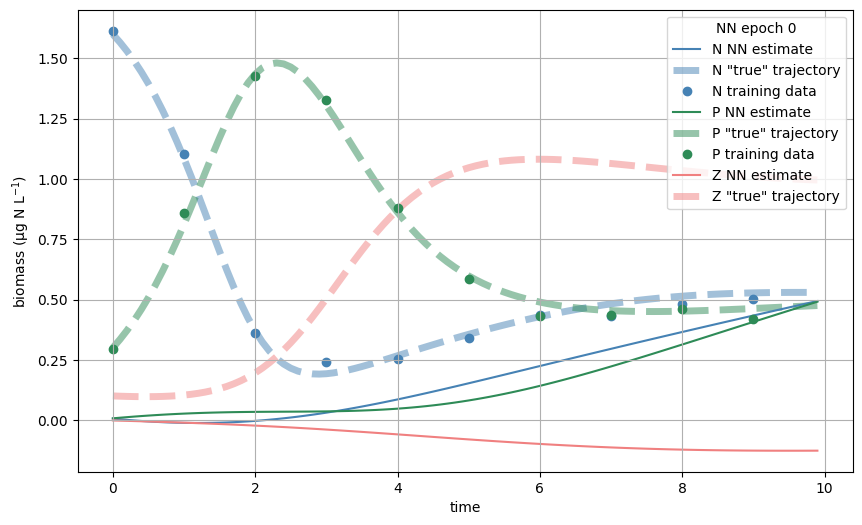

  Full domain MSE at epoch 0: 0.557346
  N MSE: 0.286977, P MSE: 0.537160, Z MSE: 0.847902


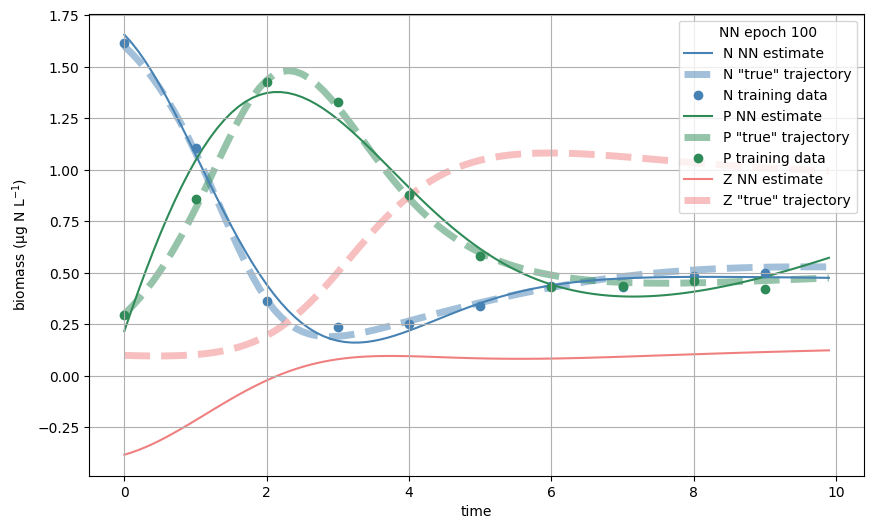

  Full domain MSE at epoch 100: 0.200032
  N MSE: 0.001290, P MSE: 0.007347, Z MSE: 0.591461


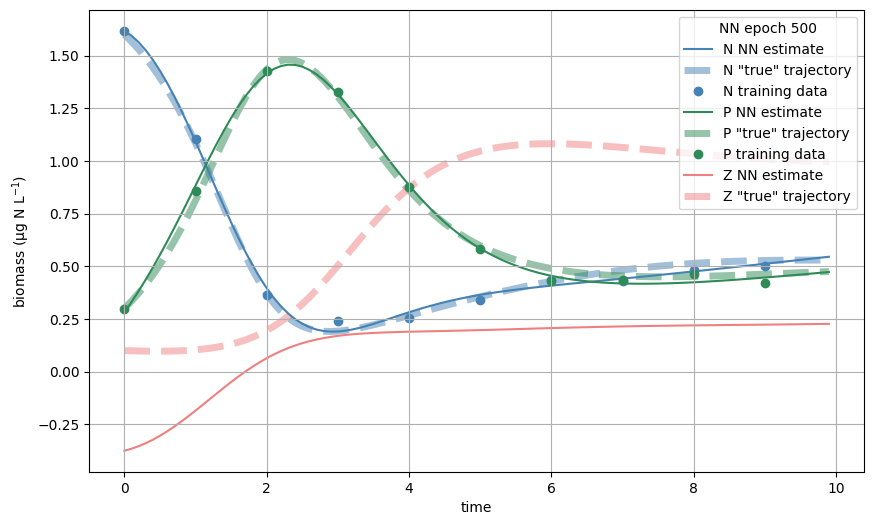

  Full domain MSE at epoch 500: 0.152270
  N MSE: 0.000539, P MSE: 0.000890, Z MSE: 0.455381


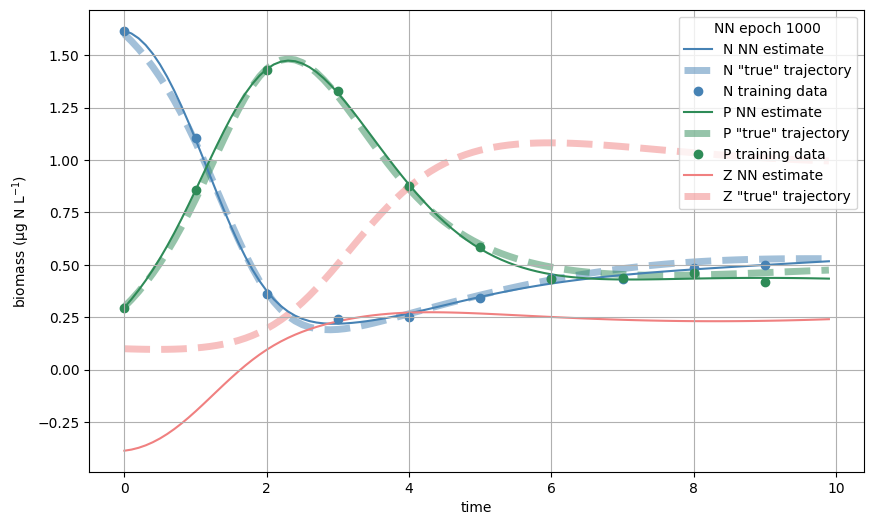

  Full domain MSE at epoch 1000: 0.138581
  N MSE: 0.000673, P MSE: 0.000623, Z MSE: 0.414447


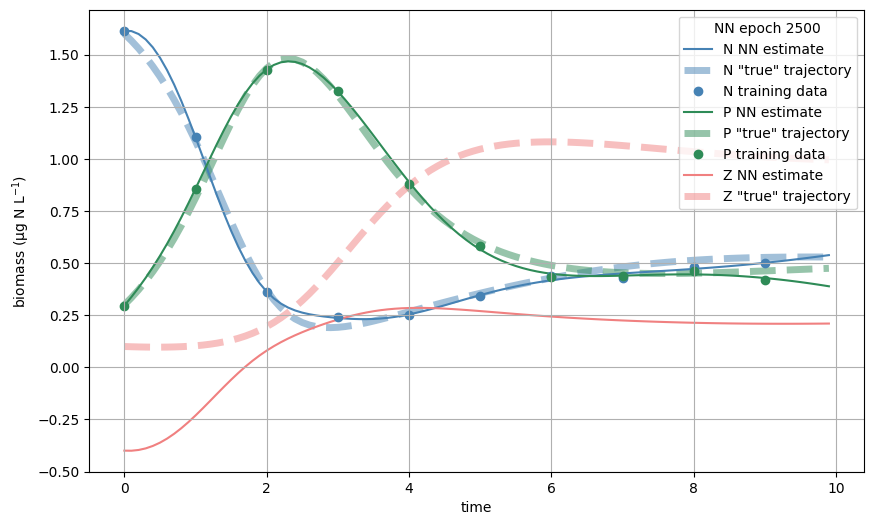

  Full domain MSE at epoch 2500: 0.143556
  N MSE: 0.001165, P MSE: 0.001009, Z MSE: 0.428493


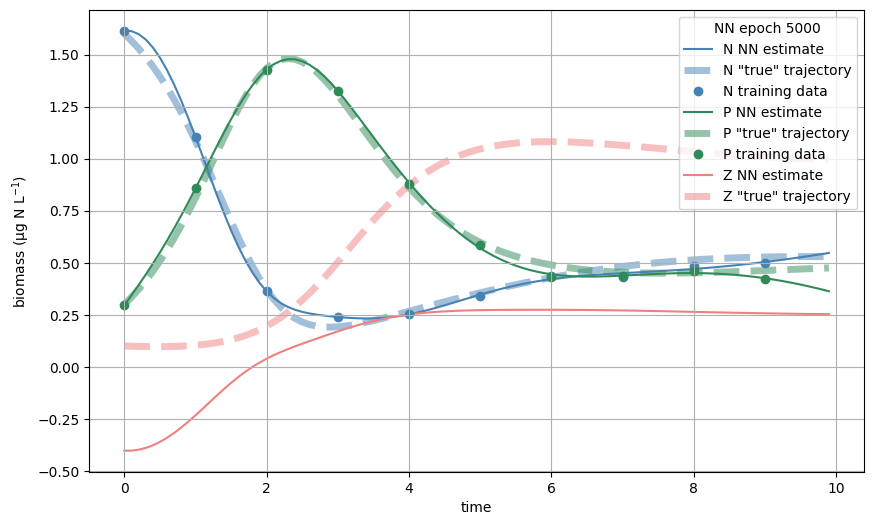

  Full domain MSE at epoch 5000: 0.136272
  N MSE: 0.001193, P MSE: 0.001204, Z MSE: 0.406419


In [9]:
print("\nStarting NN training...")
for epoch in range(n_epochs + 1):
    with tf.GradientTape() as tape:
        pred = model_nn(t_train_tensor)
        loss = tf.reduce_mean((pred[:, i_obs_slice] - state_train_tensor)**2)

    grads = tape.gradient(loss, model_nn.trainable_variables)
    optimizer.apply_gradients(zip(grads, model_nn.trainable_variables))

    if epoch in plot_epochs:
        NPZ_pred_epoch = model_nn(t_test)

        plot_result(t_train, state_train, t_full, NPZ_pred_epoch.numpy(),
                    t_true=t_full, state_true=state, epoch=epoch, model_label='NN', show=True)

        full_error = tf.reduce_mean((NPZ_pred_epoch - NPZ_test_true)**2).numpy()
        N_error = tf.reduce_mean((NPZ_pred_epoch[:, 0] - NPZ_test_true[:, 0])**2).numpy()
        P_error = tf.reduce_mean((NPZ_pred_epoch[:, 1] - NPZ_test_true[:, 1])**2).numpy()
        Z_error = tf.reduce_mean((NPZ_pred_epoch[:, 2] - NPZ_test_true[:, 2])**2).numpy()
        print(f"  Full domain MSE at epoch {epoch}: {full_error:.6f}")
        print(f"  N MSE: {N_error:.6f}, P MSE: {P_error:.6f}, Z MSE: {Z_error:.6f}")

In [10]:
# Final NN prediction on full domain
NPZ_pred_final = model_nn(t_full_tensor)

# Compute MSE/RMSE for each variable
mse_N = np.mean((state[:, 0] - NPZ_pred_final.numpy()[:, 0])**2)
mse_P = np.mean((state[:, 1] - NPZ_pred_final.numpy()[:, 1])**2)
mse_Z = np.mean((state[:, 2] - NPZ_pred_final.numpy()[:, 2])**2)
print(f"NN MSE on full domain -- N: {mse_N:.6f}, P: {mse_P:.6f}, Z: {mse_Z:.6f}")

rmse_N = np.sqrt(mse_N)
rmse_P = np.sqrt(mse_P)
rmse_Z = np.sqrt(mse_Z)
print(f"NN RMSE on full domain -- N: {rmse_N:.6f}, P: {rmse_P:.6f}, Z: {rmse_Z:.6f}")

NN MSE on full domain -- N: 0.001193, P: 0.001204, Z: 0.406419
NN RMSE on full domain -- N: 0.034544, P: 0.034693, Z: 0.637510


# Building a PINN

## From a Standard Neural Network to a PINN

**Standard Neural Network**
- Input: time `t`
- Output: `[N(t), P(t), Z(t)]`
- Loss: fits the (sparse) observations only

**Physics-Informed Neural Network (PINN)**
- Input: time `t`
- Output: `[N(t), P(t), Z(t)]`
- Loss:
  1. **Data loss** → fit the observations
  2. **Physics loss** → enforce the Lotka–Volterra equations

## Main Idea

We use TensorFlow automatic differentiation to compute  
`dN/dt`, `dP/dt`, and `dZ/dt` directly from the neural network output.

These derivatives are then compared to the governing equations,  
and the network is penalized if they do not match.

In [11]:
init_pinn = tf.keras.initializers.GlorotUniform()

model_pinn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation='gelu', kernel_initializer=init_pinn),
    tf.keras.layers.Dense(64, activation='gelu', kernel_initializer=init_pinn),
    tf.keras.layers.Dense(64, activation='gelu', kernel_initializer=init_pinn),
    tf.keras.layers.Dense(3, kernel_initializer=init_pinn)  # N, P, Z
])

### Trainable Quantities and Collocation Points

In the PINN, we learn both:
- The neural network weights
- The parameters of the NPZ equations

In addition to fitting observed data, we also enforce the governing equations at a set of **collocation points** in time.

These are points where we do not have observations, but where we require the model to satisfy the ODE.

In [12]:
np.random.seed(seed)

# add noise to generate initial estimate of parameter values
parameters_ini = {p: parameters[p] * (1.0 + relerror_param * np.random.normal()) for p in parameters}

In [13]:
# Trainable ODE parameters
pinn_Vm    = tf.Variable(parameters_ini['Vm'],    dtype=tf.float32)
pinn_ks    = tf.Variable(parameters_ini['ks'],    dtype=tf.float32)
pinn_m     = tf.Variable(parameters_ini['m'],     dtype=tf.float32)
pinn_gamma = tf.Variable(parameters_ini['gamma'], dtype=tf.float32)
pinn_Rm    = tf.Variable(parameters_ini['Rm'],    dtype=tf.float32)
pinn_ivlev = tf.Variable(parameters_ini['ivlev'], dtype=tf.float32)
pinn_q     = tf.Variable(parameters_ini['q'],     dtype=tf.float32)

ode_params = [pinn_Vm, pinn_ks, pinn_m, pinn_gamma, pinn_Rm, pinn_ivlev, pinn_q]
train_vars = model_pinn.trainable_variables + ode_params

pinn_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, epsilon=1e-8)

# Collocation points (where we enforce the ODE)
n_collocation = 200
t_phys = tf.constant(np.linspace(0, T, n_collocation), dtype=tf.float32)[:, tf.newaxis]

lam = 1.0

### Training Setup

We define the number of training epochs and the epochs at which we will visualize the model predictions.

As before, we handle missing observations using a mask, so that the data loss is only computed where observations are available.

In [14]:
n_epochs = 5000
plot_epochs = [0, 100, 500, 1000, 2500, 5000]

t_test = t_full_tensor
NPZ_test_true = tf.constant(state, dtype=tf.float32)

### PINN Loss: Fit the Data and Enforce the Governing Equations

The PINN loss has two components:

1. **Data loss** → fit the observed values  
2. **Physics loss** → enforce the Lotka–Volterra equations  

The physics loss measures how well the neural network satisfies the differential equations.

To compute the physics loss, we need the time derivatives of the network output.

We use TensorFlow automatic differentiation (`GradientTape`) to compute  
$\frac{dN}{dt}$, $\frac{dP}{dt}$, and $\frac{dZ}{dt}$ directly from the neural network.

These derivatives are evaluated at **collocation points**, which do not need to coincide with the observation times.

In [15]:
def pinn_loss(model, t_obs, state_obs, t_phys, lam,
              Vm, ks, m, gamma, Rm, ivlev, q):
    # 1. Data loss
    NPZ_pred_obs = model(t_obs)
    loss_data = tf.reduce_mean((NPZ_pred_obs[:, i_obs_slice] - state_obs)**2)

    # 2. Physics loss at collocation points
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t_phys)
        NPZ_phys = model(t_phys)
        N = NPZ_phys[:, 0:1]
        P = NPZ_phys[:, 1:2]
        Z = NPZ_phys[:, 2:3]

    dNdt = tape.gradient(N, t_phys)
    dPdt = tape.gradient(P, t_phys)
    dZdt = tape.gradient(Z, t_phys)
    del tape

    # 3. NPZ residuals
    uptake_term   = (Vm * N / (ks + N)) * P
    grazing_term  = ivlev * P * Rm * (1 - tf.exp(-ivlev * P)) * Z
    p_mortality   = m * P
    z_mortality   = q * Z

    f_N = dNdt - (-uptake_term + p_mortality + z_mortality + gamma * grazing_term)
    f_P = dPdt - (uptake_term - p_mortality - grazing_term)
    f_Z = dZdt - ((1 - gamma) * grazing_term - z_mortality)

    loss_phys = tf.reduce_mean(f_N**2 + f_P**2 + f_Z**2)

    total_loss = loss_data + lam * loss_phys
    return total_loss, loss_data, loss_phys

### Train the PINN

We train the PINN by minimizing the combined loss (data + physics) using gradient-based optimization.

At each epoch:
- We compute the total loss using `pinn_loss`
- We compute gradients with respect to both the neural network weights and the ODE parameters
- We update all trainable variables using the optimizer

We periodically visualize the model prediction and monitor:
- Total loss
- Data loss
- Physics loss
- Learned ODE parameters


Starting PINN training...
Epoch 0: Total = 2.373613 | Data = 0.637307 | Physics = 1.736306 | Elapsed = 0.15 s


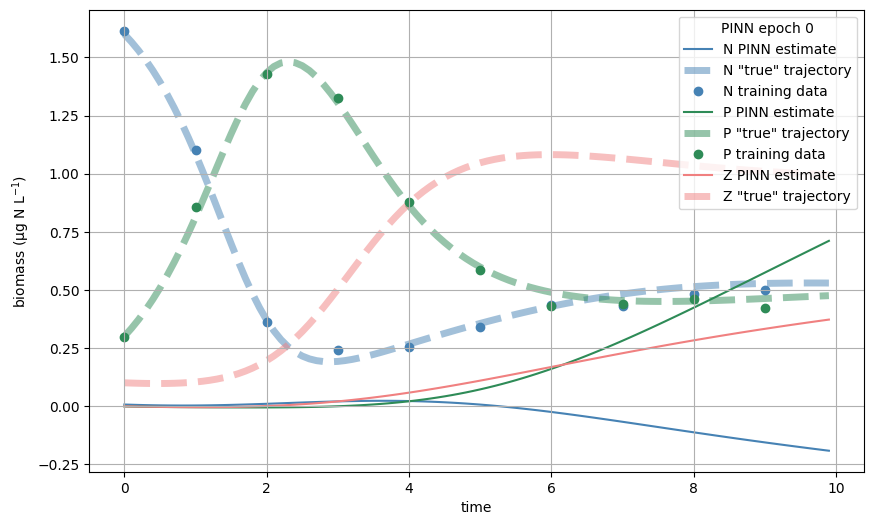

  Full domain MSE: 0.488662
  N MSE: 0.442790, P MSE: 0.566586, Z MSE: 0.456611
  Learned parameters: Vm=2.0983, ks=0.9872, m=0.1055, gamma=0.3447, Rm=1.4639, ivlev=0.9756, q=0.2306

Epoch 100: Total = 0.161723 | Data = 0.140226 | Physics = 0.021497 | Elapsed = 3.64 s


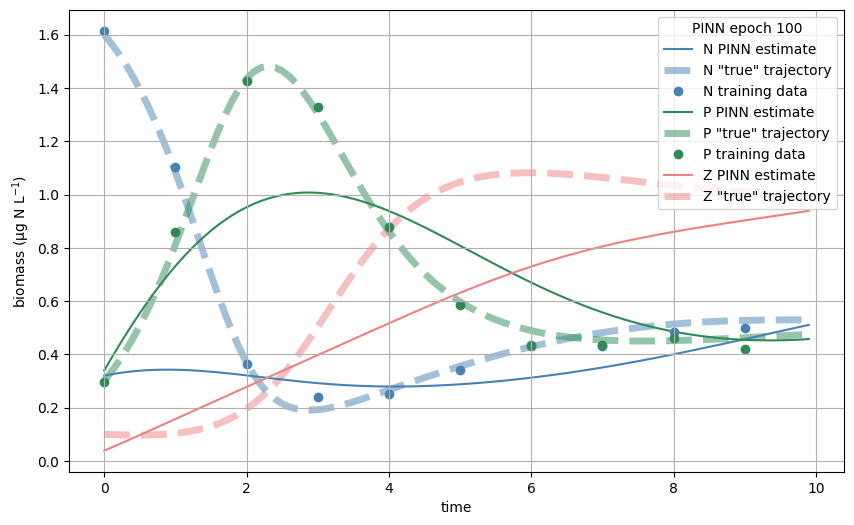

  Full domain MSE: 0.080472
  N MSE: 0.143721, P MSE: 0.042205, Z MSE: 0.055488
  Learned parameters: Vm=2.0817, ks=0.9964, m=0.1412, gamma=0.3407, Rm=1.4827, ivlev=0.9950, q=0.2181

Epoch 500: Total = 0.001470 | Data = 0.000806 | Physics = 0.000664 | Elapsed = 17.62 s


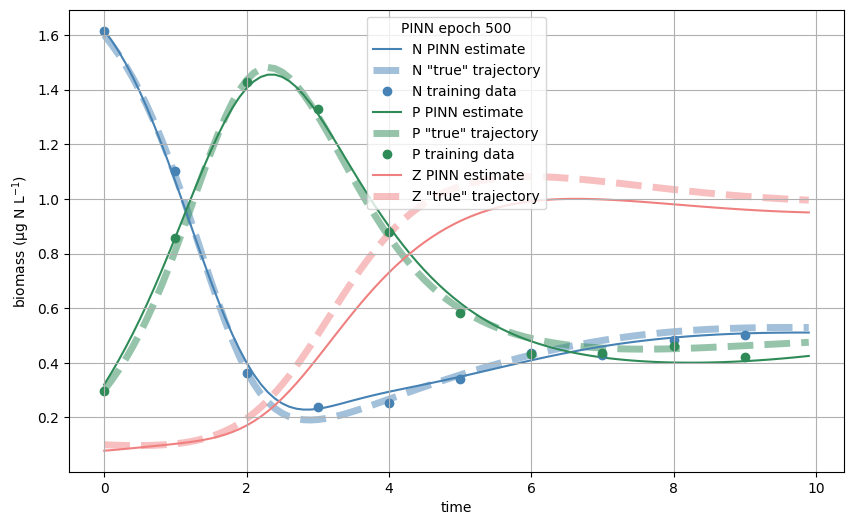

  Full domain MSE: 0.002723
  N MSE: 0.000536, P MSE: 0.001347, Z MSE: 0.006287
  Learned parameters: Vm=2.0610, ks=1.0033, m=0.1808, gamma=0.3835, Rm=1.5076, ivlev=1.0273, q=0.1445

Epoch 1000: Total = 0.000588 | Data = 0.000392 | Physics = 0.000196 | Elapsed = 34.75 s


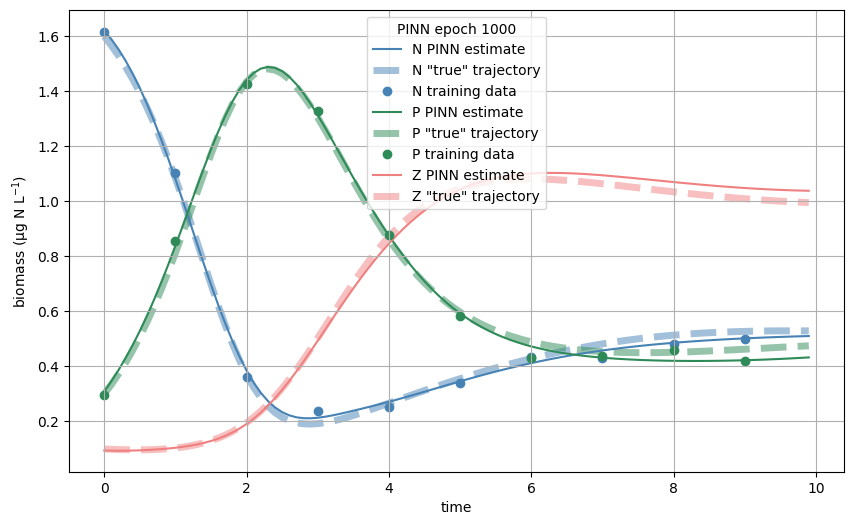

  Full domain MSE: 0.000480
  N MSE: 0.000351, P MSE: 0.000521, Z MSE: 0.000568
  Learned parameters: Vm=2.0708, ks=1.0005, m=0.1559, gamma=0.3167, Rm=1.4756, ivlev=0.9898, q=0.1610

Epoch 2500: Total = 0.000407 | Data = 0.000344 | Physics = 0.000063 | Elapsed = 85.60 s


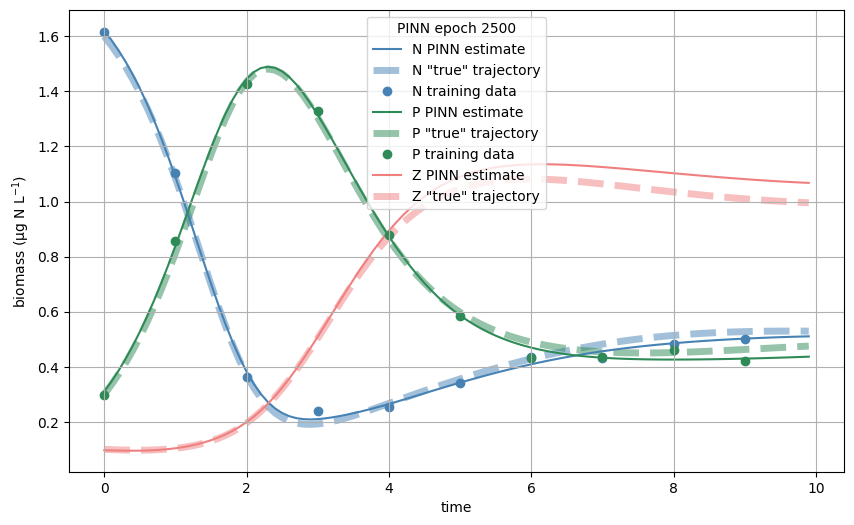

  Full domain MSE: 0.000974
  N MSE: 0.000356, P MSE: 0.000450, Z MSE: 0.002116
  Learned parameters: Vm=2.0719, ks=1.0019, m=0.1603, gamma=0.2736, Rm=1.4555, ivlev=0.9671, q=0.1666

Epoch 5000: Total = 0.000414 | Data = 0.000334 | Physics = 0.000080 | Elapsed = 172.51 s


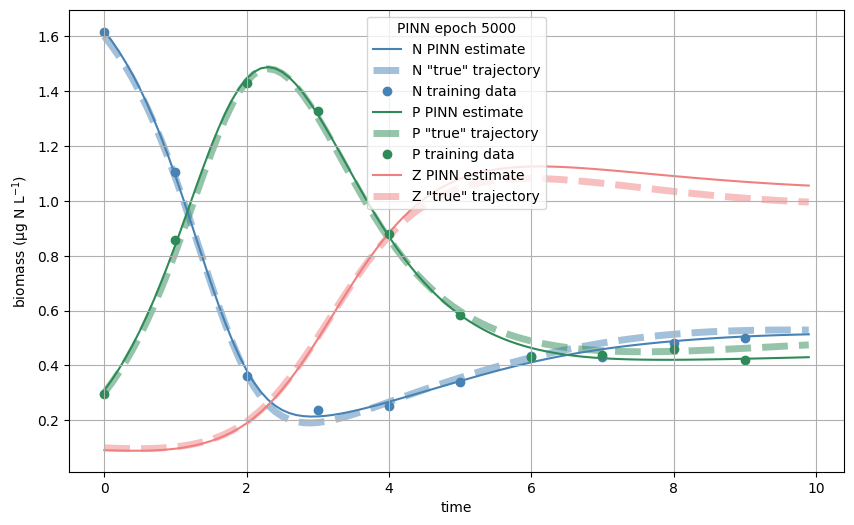

  Full domain MSE: 0.000774
  N MSE: 0.000309, P MSE: 0.000601, Z MSE: 0.001412
  Learned parameters: Vm=2.1159, ks=0.9987, m=0.1856, gamma=0.2527, Rm=1.4587, ivlev=0.9591, q=0.1700

PINN training finished in 172.57 seconds (2.88 minutes)


In [16]:
print("\nStarting PINN training...")
start_time = time.time()

loss_history = {k: [] for k in ('total', 'data', 'dynamics')}

for epoch in range(n_epochs + 1):
    with tf.GradientTape() as tape:
        loss_total, loss_data_val, loss_phys_val = pinn_loss(
            model_pinn, t_train_tensor, state_train_tensor, t_phys, lam,
            pinn_Vm, pinn_ks, pinn_m, pinn_gamma, pinn_Rm, pinn_ivlev, pinn_q
        )

    grads = tape.gradient(loss_total, train_vars)
    pinn_optimizer.apply_gradients(zip(grads, train_vars))

    loss_history['total'].append(loss_total.numpy())
    loss_history['data'].append(loss_data_val.numpy())
    loss_history['dynamics'].append(loss_phys_val.numpy())

    if epoch in plot_epochs:
        elapsed = time.time() - start_time
        NPZ_pred_epoch = model_pinn(t_test)

        print(f"Epoch {epoch}: "
              f"Total = {loss_total.numpy():.6f} | "
              f"Data = {loss_data_val.numpy():.6f} | "
              f"Physics = {loss_phys_val.numpy():.6f} | "
              f"Elapsed = {elapsed:.2f} s")

        plot_result(t_train, state_train, t_full, NPZ_pred_epoch.numpy(),
                    t_true=t_full, state_true=state, epoch=epoch, model_label='PINN', show=True)

        full_error = tf.reduce_mean((NPZ_pred_epoch - NPZ_test_true)**2).numpy()
        N_error = tf.reduce_mean((NPZ_pred_epoch[:, 0] - NPZ_test_true[:, 0])**2).numpy()
        P_error = tf.reduce_mean((NPZ_pred_epoch[:, 1] - NPZ_test_true[:, 1])**2).numpy()
        Z_error = tf.reduce_mean((NPZ_pred_epoch[:, 2] - NPZ_test_true[:, 2])**2).numpy()

        print(f"  Full domain MSE: {full_error:.6f}")
        print(f"  N MSE: {N_error:.6f}, P MSE: {P_error:.6f}, Z MSE: {Z_error:.6f}")
        print(f"  Learned parameters:"
              f" Vm={pinn_Vm.numpy():.4f}, ks={pinn_ks.numpy():.4f},"
              f" m={pinn_m.numpy():.4f}, gamma={pinn_gamma.numpy():.4f},"
              f" Rm={pinn_Rm.numpy():.4f}, ivlev={pinn_ivlev.numpy():.4f},"
              f" q={pinn_q.numpy():.4f}\n")

total_elapsed = time.time() - start_time
print(f"PINN training finished in {total_elapsed:.2f} seconds ({total_elapsed/60:.2f} minutes)")

### Evaluating the PINN results

We evaluate the PINN on the full time domain and compare the learned ODE parameters to their true values.
Good parameter recovery is a key advantage of PINNs over standard neural networks -- not only do we get a good fit to the data, we also recover physically meaningful parameters.

In [18]:
# Final PINN prediction on full domain
NPZ_pinn_pred = model_pinn(t_full_tensor)

# Compute MSE/RMSE for each variable
mse_N = np.mean((state[:, 0] - NPZ_pinn_pred.numpy()[:, 0])**2)
mse_P = np.mean((state[:, 1] - NPZ_pinn_pred.numpy()[:, 1])**2)
mse_Z = np.mean((state[:, 2] - NPZ_pinn_pred.numpy()[:, 2])**2)
print(f"PINN MSE -- N: {mse_N:.6f}, P: {mse_P:.6f}, Z: {mse_Z:.6f}")

rmse_N, rmse_P, rmse_Z = np.sqrt(mse_N), np.sqrt(mse_P), np.sqrt(mse_Z)
print(f"PINN RMSE -- N: {rmse_N:.6f}, P: {rmse_P:.6f}, Z: {rmse_Z:.6f}\n")

# Compare learned ODE parameters to true values
print(f"True Vm={parameters['Vm']:.4f}, Learned Vm={pinn_Vm.numpy():.4f}")
print(f"True ks={parameters['ks']:.4f}, Learned ks={pinn_ks.numpy():.4f}")
print(f"True m={parameters['m']:.4f}, Learned m={pinn_m.numpy():.4f}")
print(f"True gamma={parameters['gamma']:.4f}, Learned gamma={pinn_gamma.numpy():.4f}")
print(f"True Rm={parameters['Rm']:.4f}, Learned Rm={pinn_Rm.numpy():.4f}")
print(f"True ivlev={parameters['ivlev']:.4f}, Learned ivlev={pinn_ivlev.numpy():.4f}")
print(f"True q={parameters['q']:.4f}, Learned q={pinn_q.numpy():.4f}")

PINN MSE -- N: 0.000309, P: 0.000601, Z: 0.001412
PINN RMSE -- N: 0.017582, P: 0.024516, Z: 0.037574

True Vm=2.0000, Learned Vm=2.1159
True ks=1.0000, Learned ks=0.9987
True m=0.1000, Learned m=0.1856
True gamma=0.3000, Learned gamma=0.2527
True Rm=1.5000, Learned Rm=1.4587
True ivlev=1.0000, Learned ivlev=0.9591
True q=0.2000, Learned q=0.1700


### Training loss history

The top panel shows how the total, data, and dynamics losses evolve over training. 
Ideally both the data and dynamics loss decrease together.
The bottom panel shows the fraction of the total loss coming from the data term -- as the physics loss grows in influence, this fraction decreases.

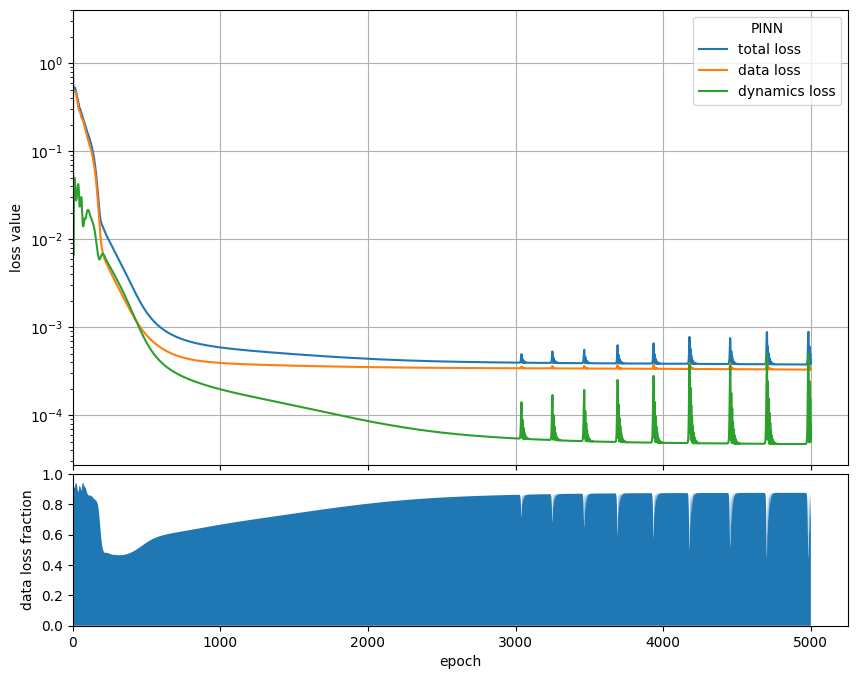

In [19]:
# Loss history plots
fig, axs = plt.subplots(nrows=2, figsize=(10, 8), sharex=True,
                         gridspec_kw={'height_ratios': (3, 1), 'hspace': 0.03})
ax = axs[0]
for key in loss_history:
    ax.plot(np.arange(1, len(loss_history[key])+1), loss_history[key], label=f'{key} loss')
ax.set(ylabel='loss value', yscale='log')
ax.grid(True)
ax.legend(title='PINN')
ax.set_xlim(left=0)

ax = axs[1]
ax.fill_between(np.arange(1, len(loss_history['total'])+1), 0,
                np.array(loss_history['data']) / np.array(loss_history['total']))
ax.set(xlabel='epoch', ylabel='data loss fraction', ylim=(0, 1))
plt.show()